In [10]:
from google.colab import drive
drive.mount('/content/drive')

%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/helper/helper.ipynb'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **1. Decision Tree Learning**

Decision tree classifiers are highly interpretable models that break down data by asking a series of questions.

* **Structure:** They start at a **root node**, split the data at **internal nodes** based on specific features (e.g., "Is sepal width $\geq$ 2.8 cm?"), and flow down **branches** until reaching pure **leaf nodes** where a final class label is assigned.
* **Overfitting:** Because decision trees can grow very deep and complex, they easily overfit the training data. Setting a maximum depth limit (pruning) is standard practice.

---

## 1.1. Maximizing Information Gain (IG)
To decide exactly *where* and *how* to split the data at each node, the tree learning algorithm optimizes an objective function: it seeks to maximize **Information Gain (IG)**.

Information Gain is simply the difference between the impurity of the parent node and the sum of the child node impurities. The lower the impurity of the child nodes, the higher the information gain.

**The Objective Function:**
$$IG(D_p, f) = I(D_p) - \sum_{j=1}^{m} \frac{N_j}{N_p} I(D_j)$$

Since most libraries (like scikit-learn) implement binary decision trees, this usually simplifies to:
$$IG(D_p, f) = I(D_p) - \frac{N_{left}}{N_p}I(D_{left}) - \frac{N_{right}}{N_p}I(D_{right})$$

*(Where $f$ is the splitting feature, $D_p$ and $D_j$ are the parent and child datasets, $I$ is the impurity measure, and $N$ represents the number of examples).*

---

## 1.2. The 3 Common Impurity Measures ($I$)

To calculate the Information Gain, we need a way to measure the "impurity" ($I$) of a node. There are three common criteria used in binary decision trees:

#### 1. Entropy ($I_H$)
Attempts to maximize the mutual information in the tree. It is $0$ if a node is perfectly pure (all examples belong to one class) and maximal ($1$ in a binary setting) if the classes are perfectly mixed.
$$I_H(t) = - \sum_{i=1}^{c} p(i|t) \log_2 p(i|t)$$

#### 2. Gini Impurity ($I_G$)
A criterion to minimize the probability of misclassification. In practice, Gini impurity and Entropy yield very similar results and have similar graphical shapes. It is often not worth the time to rigorously evaluate both.
$$I_G(t) = 1 - \sum_{i=1}^{c} p(i|t)^2$$

#### 3. Classification Error ($I_E$)
While useful for *pruning* a tree, Classification Error is not recommended for *growing* one. It is less sensitive to changes in the class probabilities of the nodes, meaning it might fail to prefer a split that produces purer nodes compared to Gini or Entropy.
$$I_E(t) = 1 - \max\{p(i|t)\}$$

> **Note on $p(i|t)$:** This represents the proportion of examples that belong to class $i$ for a particular node $t$.

**Visualize the entropy values for different class distributions.**


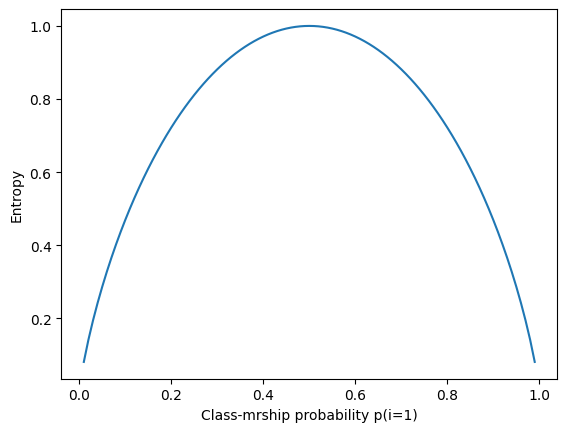

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def entropy(p):
     return - p * np.log2(p) - (1 - p) * np.log2((1 - p))

x = np.arange(0.0, 1.0, 0.01)
ent = [entropy(p) if p != 0 else None for p in x]

plt.ylabel('Entropy')
plt.xlabel('Class-mrship probability p(i=1)')
plt.plot(x, ent)
plt.show()

**Plot impurity indices for the probability range [0, 1] for class 1.**

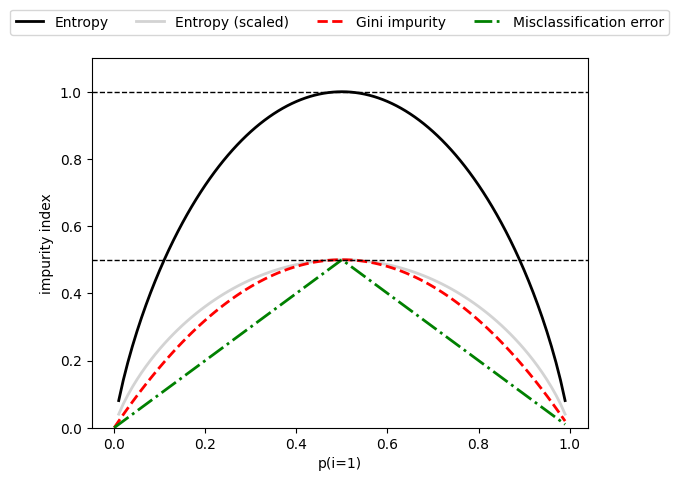

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def gini(p):
    return p*(1 - p) + (1 - p)*(1 - (1-p))

def entropy(p):
    return - p*np.log2(p) - (1 - p)*np.log2((1 - p))

def error(p):
    return 1 - np.max([p, 1 - p])

x = np.arange(0.0, 1.0, 0.01)
ent = [entropy(p) if p != 0 else None for p in x]
sc_ent = [e*0.5 if e else None for e in ent]
err = [error(i) for i in x]

fig = plt.figure()
ax = plt.subplot(111)
for i, lab, ls, c, in zip([ent, sc_ent, gini(x), err],
                          ['Entropy', 'Entropy (scaled)',
                           'Gini impurity',
                           'Misclassification error'],
                          ['-', '-', '--', '-.'],
                          ['black', 'lightgray',
                           'red', 'green', 'cyan']):
    line = ax.plot(x, i, label=lab,
                  linestyle=ls, lw=2, color=c)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),
          ncol=5, fancybox=True, shadow=False)

ax.axhline(y=0.5, linewidth=1, color='k', linestyle='--')
ax.axhline(y=1.0, linewidth=1, color='k', linestyle='--')
plt.ylim([0, 1.1])
plt.xlabel('p(i=1)')
plt.ylabel('impurity index')
plt.show()



# **2. Building a Decision Tree: Scikit-learn**

Decision trees are powerful algorithms that build complex decision boundaries by dividing the feature space into rectangles.

### 2.1. Key Characteristics
* **Axis-Parallel Boundaries:** The algorithm splits data using perpendicular lines, resulting in rectangular decision regions.
* **No Feature Scaling Required:** Unlike many other machine learning algorithms, decision trees do not require feature scaling (standardization or normalization) to work effectively, though you might still use it for visualization purposes.
* **Prone to Overfitting:** The deeper a decision tree grows, the more complex the decision boundary becomes. This can easily lead to overfitting the training data.

### 2.2. Training the Model
In scikit-learn, you can control overfitting by limiting the depth of the tree. A common approach is setting a maximum depth (e.g., `max_depth=4`) and using the **Gini impurity** as the criterion for splitting nodes.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

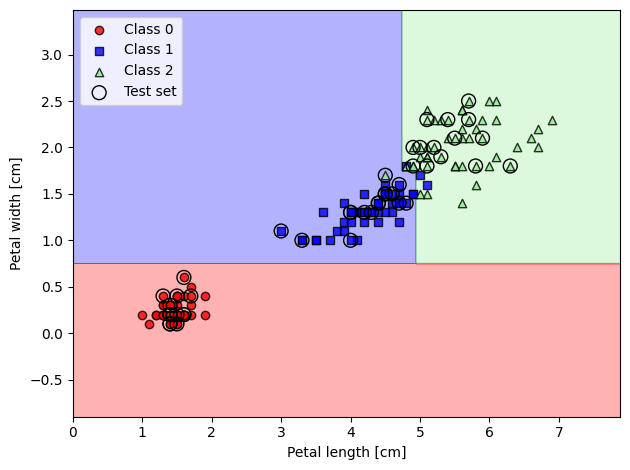

In [14]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=1)
tree_model.fit(X_train, y_train)

X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))

plot_decision_regions(X_combined,
                       y_combined,
                       classifier=tree_model,
                       test_idx=range(105, 150))
plt.xlabel('Petal length [cm]')
plt.ylabel('Petal width [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 2.3 Visualizing the Tree
Scikit-learn provides convenient tools to visualize both the decision boundaries and the internal logic of the tree model.

**Visualizing the Tree Structure:**
You can use `sklearn.tree.plot_tree` to generate a flowchart-like visualization of the model.

#### 1. Interpreting the Tree Plot
When reading the outputted decision tree figure:
* **Branches:** The left branch always corresponds to **"True"** and the right branch corresponds to **"False"** for the given splitting criterion at that node.
* **Node Information:** Each node displays the split condition (if not a leaf), the current Gini impurity, the number of samples, and the distribution of those samples across the classes.
* **Purity:** A node with a Gini impurity of `0.0` is completely "pure," meaning it only contains samples from a single class. For example, in the Iris dataset, an initial split of `sepal width <= 0.75 cm` might perfectly isolate the `Iris-setosa` class into a pure left child node.

#### 2. Handling Overfitting & Pruning
If your model is overfitting, you need to restrict its complexity:
-  **Pre-pruning (Manual):** Scikit-learn does not support manual post-pruning. Instead, you can pre-prune the tree by adjusting hyperparameters during training, such as lowering the `max_depth` (e.g., changing it from 4 to 3).
-  **Cost Complexity Pruning (Automatic):** Scikit-learn offers an automatic cost complexity post-pruning procedure for a more advanced, automated approach to reducing tree size.

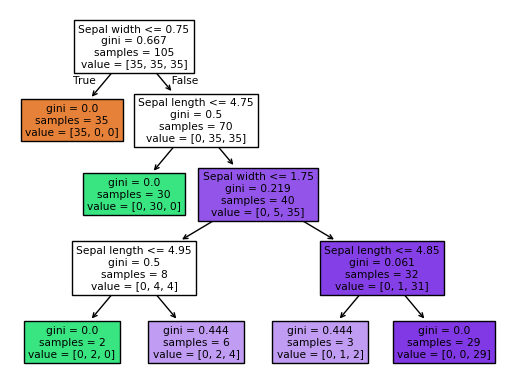

In [15]:
from sklearn import tree
feature_names = ['Sepal length', 'Sepal width',
                  'Petal length', 'Petal width']
tree.plot_tree(tree_model,
                feature_names=feature_names,
                filled=True)
plt.show()

# **3. Combining Multiple Decision Trees via Random Forests**

Ensemble methods like random forests are highly popular in machine learning because of their excellent classification performance, scalability, ease of use, and robustness against overfitting.

A random forest can be considered an ensemble of decision trees. The core idea is to average multiple (often deep) decision trees that individually suffer from high variance to build a more robust model that generalizes better to unseen data.

### 3.1. The Random Forest Algorithm
The algorithm can be summarized in four main steps:

1. **Bootstrap Sampling:** Draw a random bootstrap sample of size $n$ (randomly choose $n$ examples from the training dataset *with replacement*).
2. **Grow a Decision Tree:** Grow a tree from the bootstrap sample. At each node:
   * Randomly select $d$ features *without replacement*.
   * Split the node using the feature that provides the best split according to the objective function (e.g., maximizing information gain or using Gini impurity).
3. **Repeat:** Repeat steps 1 and 2 $k$ times to build $k$ trees.
4. **Aggregate:** Aggregate the predictions of each tree to assign the final class label by **majority vote**.

### 3.2. Hyperparameters and the Bias-Variance Tradeoff
A major advantage of random forests is that they require minimal hyperparameter tuning. Because averaging the predictions protects against noise, you typically don't need to prune the individual trees.

* **Number of Trees ($k$):** The primary parameter you need to care about. Generally, a larger number of trees improves performance at the expense of increased computational cost.
* **Bootstrap Sample Size ($n$):** Controls the bias-variance tradeoff.
  * *Decreasing* $n$ shrinks the sample size, increasing the randomness and diversity among trees. This helps reduce overfitting but might lower overall performance.
  * *Increasing* $n$ makes the bootstrap samples (and thus the trees) more similar to each other, which fits the training data more closely but increases the risk of overfitting.
  * *Default:* In scikit-learn, the default size of the bootstrap sample is equal to the total number of training examples.
* **Number of Features ($d$):** At each split, you want to choose a value smaller than the total number of features ($m$). A standard default used in scikit-learn is $d = \sqrt{m}$.

**Implementation in Scikit-Learn**


In [16]:
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))

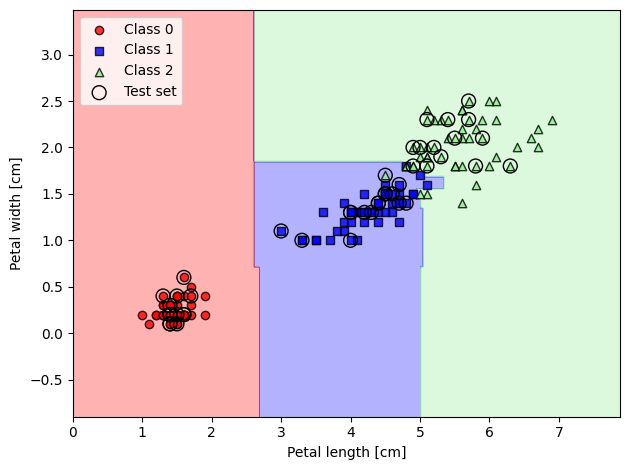

In [17]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Initialize the Random Forest Classifier
# n_estimators: Number of trees (k)
# n_jobs: Number of CPU cores used to parallelize training
forest = RandomForestClassifier(n_estimators=25,
                                random_state=1,
                                n_jobs=2)

# Train the model
forest.fit(X_train, y_train)

# Plotting decision regions (assuming a custom plot_decision_regions function is defined)
plot_decision_regions(X_combined, y_combined,
                      classifier=forest,
                      test_idx=range(105, 150))

plt.xlabel('Petal length [cm]')
plt.ylabel('Petal width [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()